In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('wine.csv')
print(df.head())

   Type  Alcohol  Malic   Ash  Alcalinity  Magnesium  Phenols  Flavanoids  \
0     1    14.23   1.71  2.43        15.6        127     2.80        3.06   
1     1    13.20   1.78  2.14        11.2        100     2.65        2.76   
2     1    13.16   2.36  2.67        18.6        101     2.80        3.24   
3     1    14.37   1.95  2.50        16.8        113     3.85        3.49   
4     1    13.24   2.59  2.87        21.0        118     2.80        2.69   

   Nonflavanoids  Proanthocyanins  Color   Hue  Dilution  Proline  
0           0.28             2.29   5.64  1.04      3.92     1065  
1           0.26             1.28   4.38  1.05      3.40     1050  
2           0.30             2.81   5.68  1.03      3.17     1185  
3           0.24             2.18   7.80  0.86      3.45     1480  
4           0.39             1.82   4.32  1.04      2.93      735  


In [4]:
print(df.info())
print(df.isnull().sum())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Type             178 non-null    int64  
 1   Alcohol          178 non-null    float64
 2   Malic            178 non-null    float64
 3   Ash              178 non-null    float64
 4   Alcalinity       178 non-null    float64
 5   Magnesium        178 non-null    int64  
 6   Phenols          178 non-null    float64
 7   Flavanoids       178 non-null    float64
 8   Nonflavanoids    178 non-null    float64
 9   Proanthocyanins  178 non-null    float64
 10  Color            178 non-null    float64
 11  Hue              178 non-null    float64
 12  Dilution         178 non-null    float64
 13  Proline          178 non-null    int64  
dtypes: float64(11), int64(3)
memory usage: 19.6 KB
None
Type               0
Alcohol            0
Malic              0
Ash                0
Alcalinity        

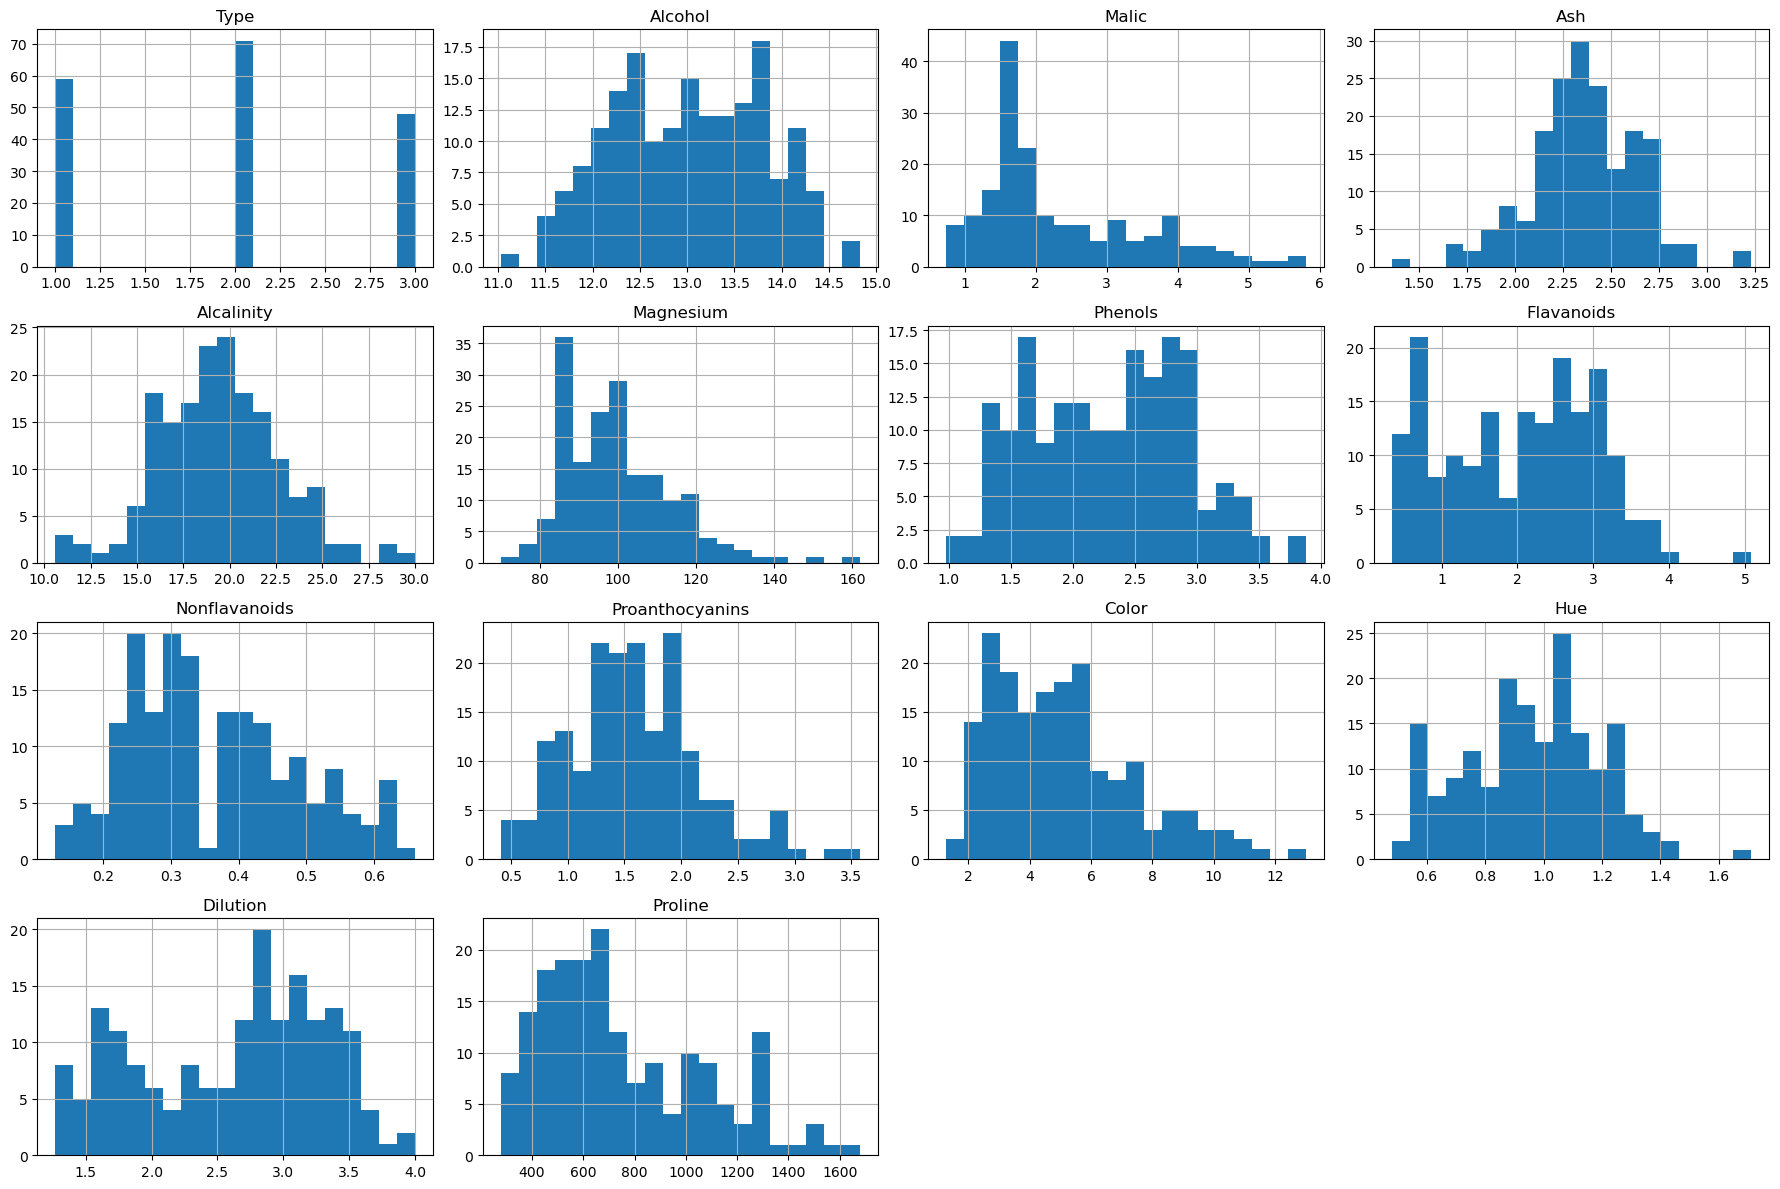

In [5]:
df.hist(bins=20, figsize=(18, 12))
plt.tight_layout()
plt.show()

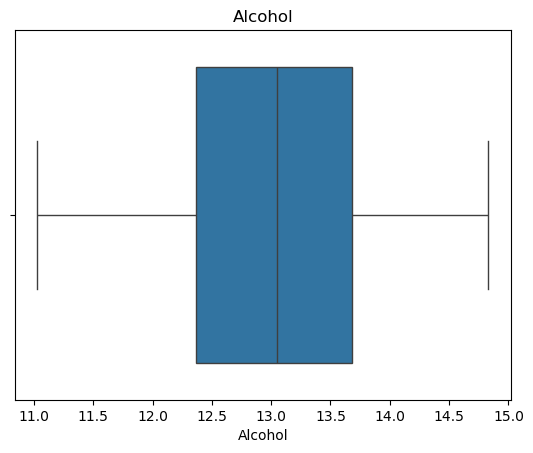

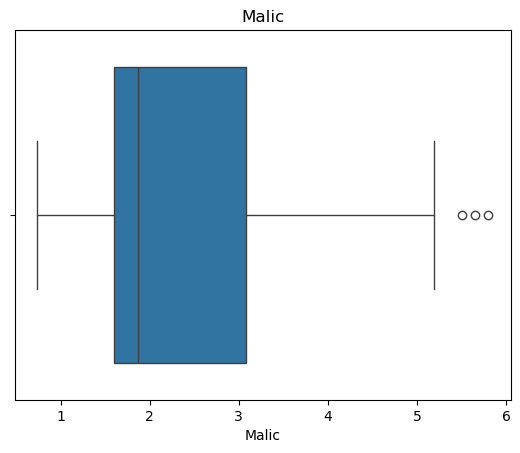

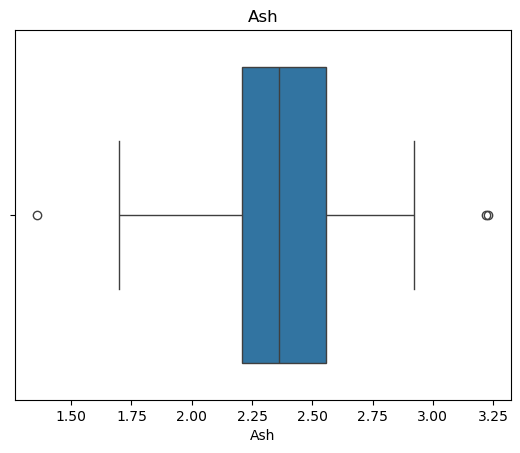

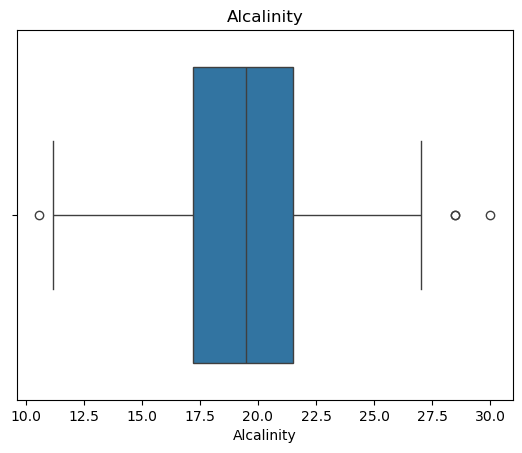

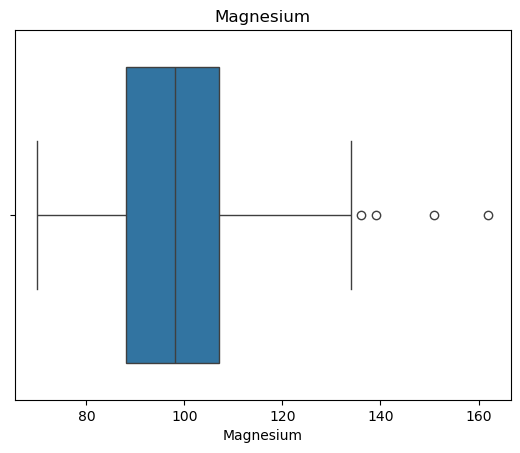

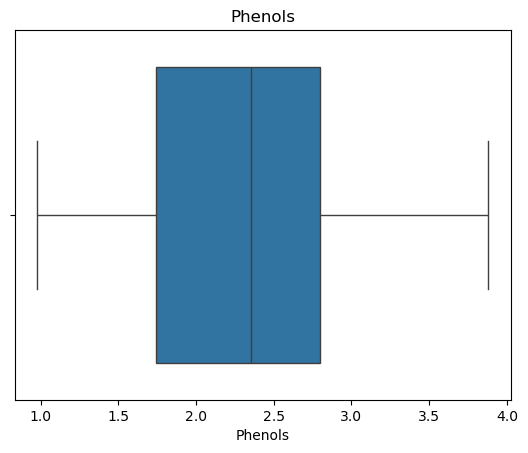

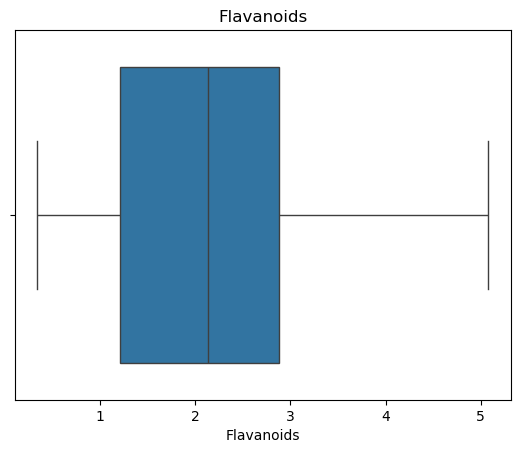

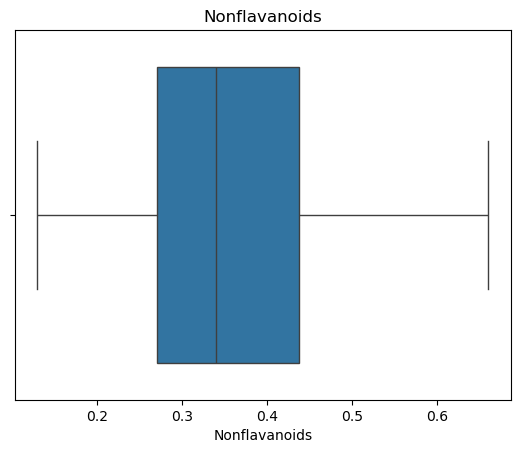

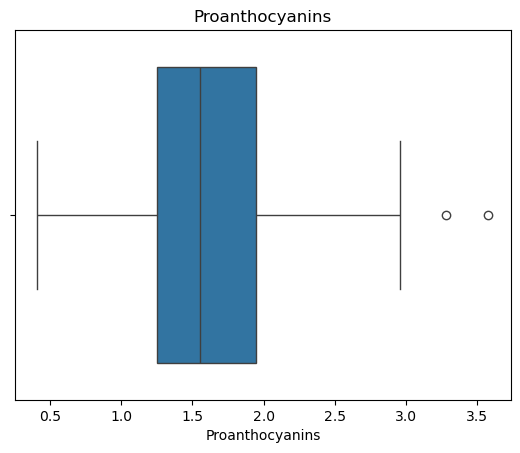

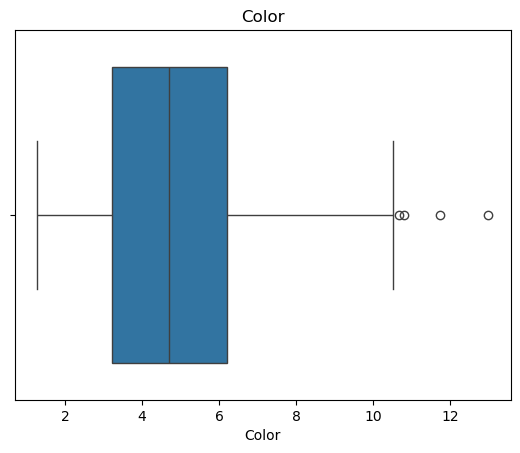

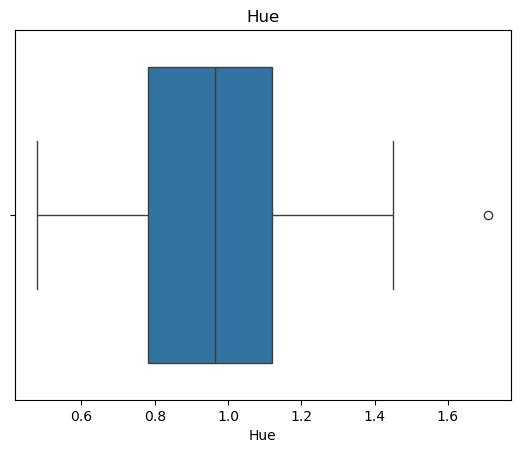

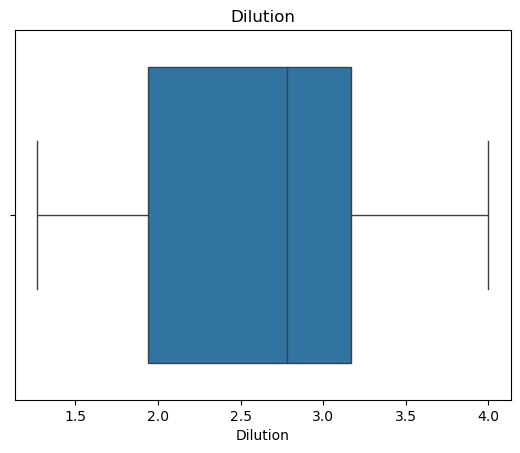

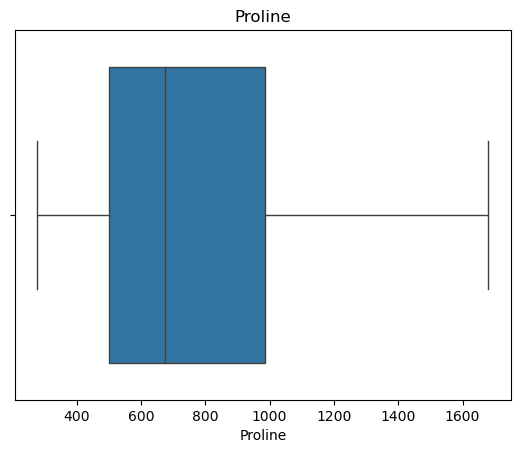

In [6]:
num_cols = df.columns[1:]
for col in num_cols:
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

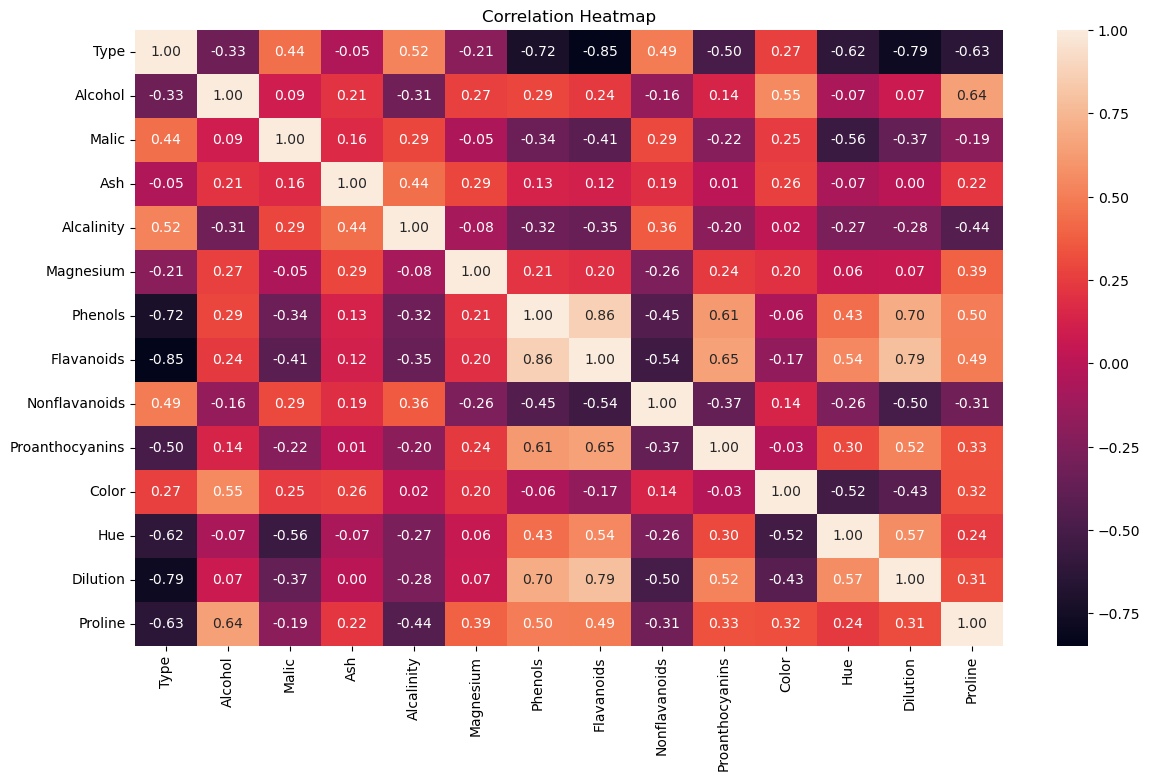

In [7]:
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# I created a heatmap to understand relationships between features.

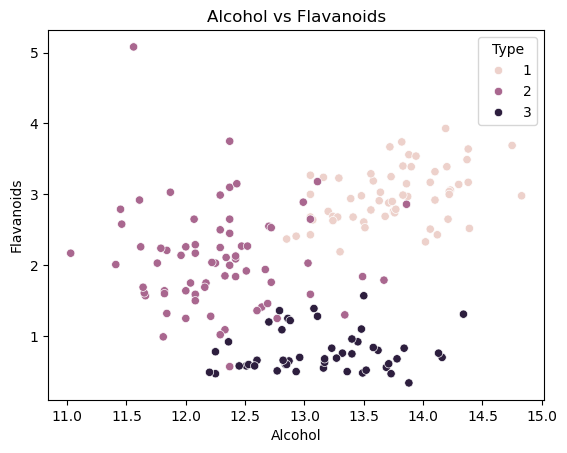

In [12]:
# scatter plots to see relationships between features
sns.scatterplot(x='Alcohol',y='Flavanoids',hue='Type',data=df)
plt.title('Alcohol vs Flavanoids')
plt.show()

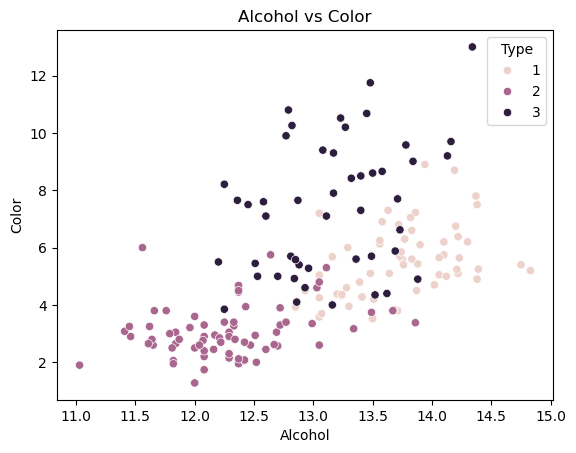

In [13]:
sns.scatterplot(x='Alcohol',y='Color',hue='Type',data=df)
plt.title('Alcohol vs Color')
plt.show()

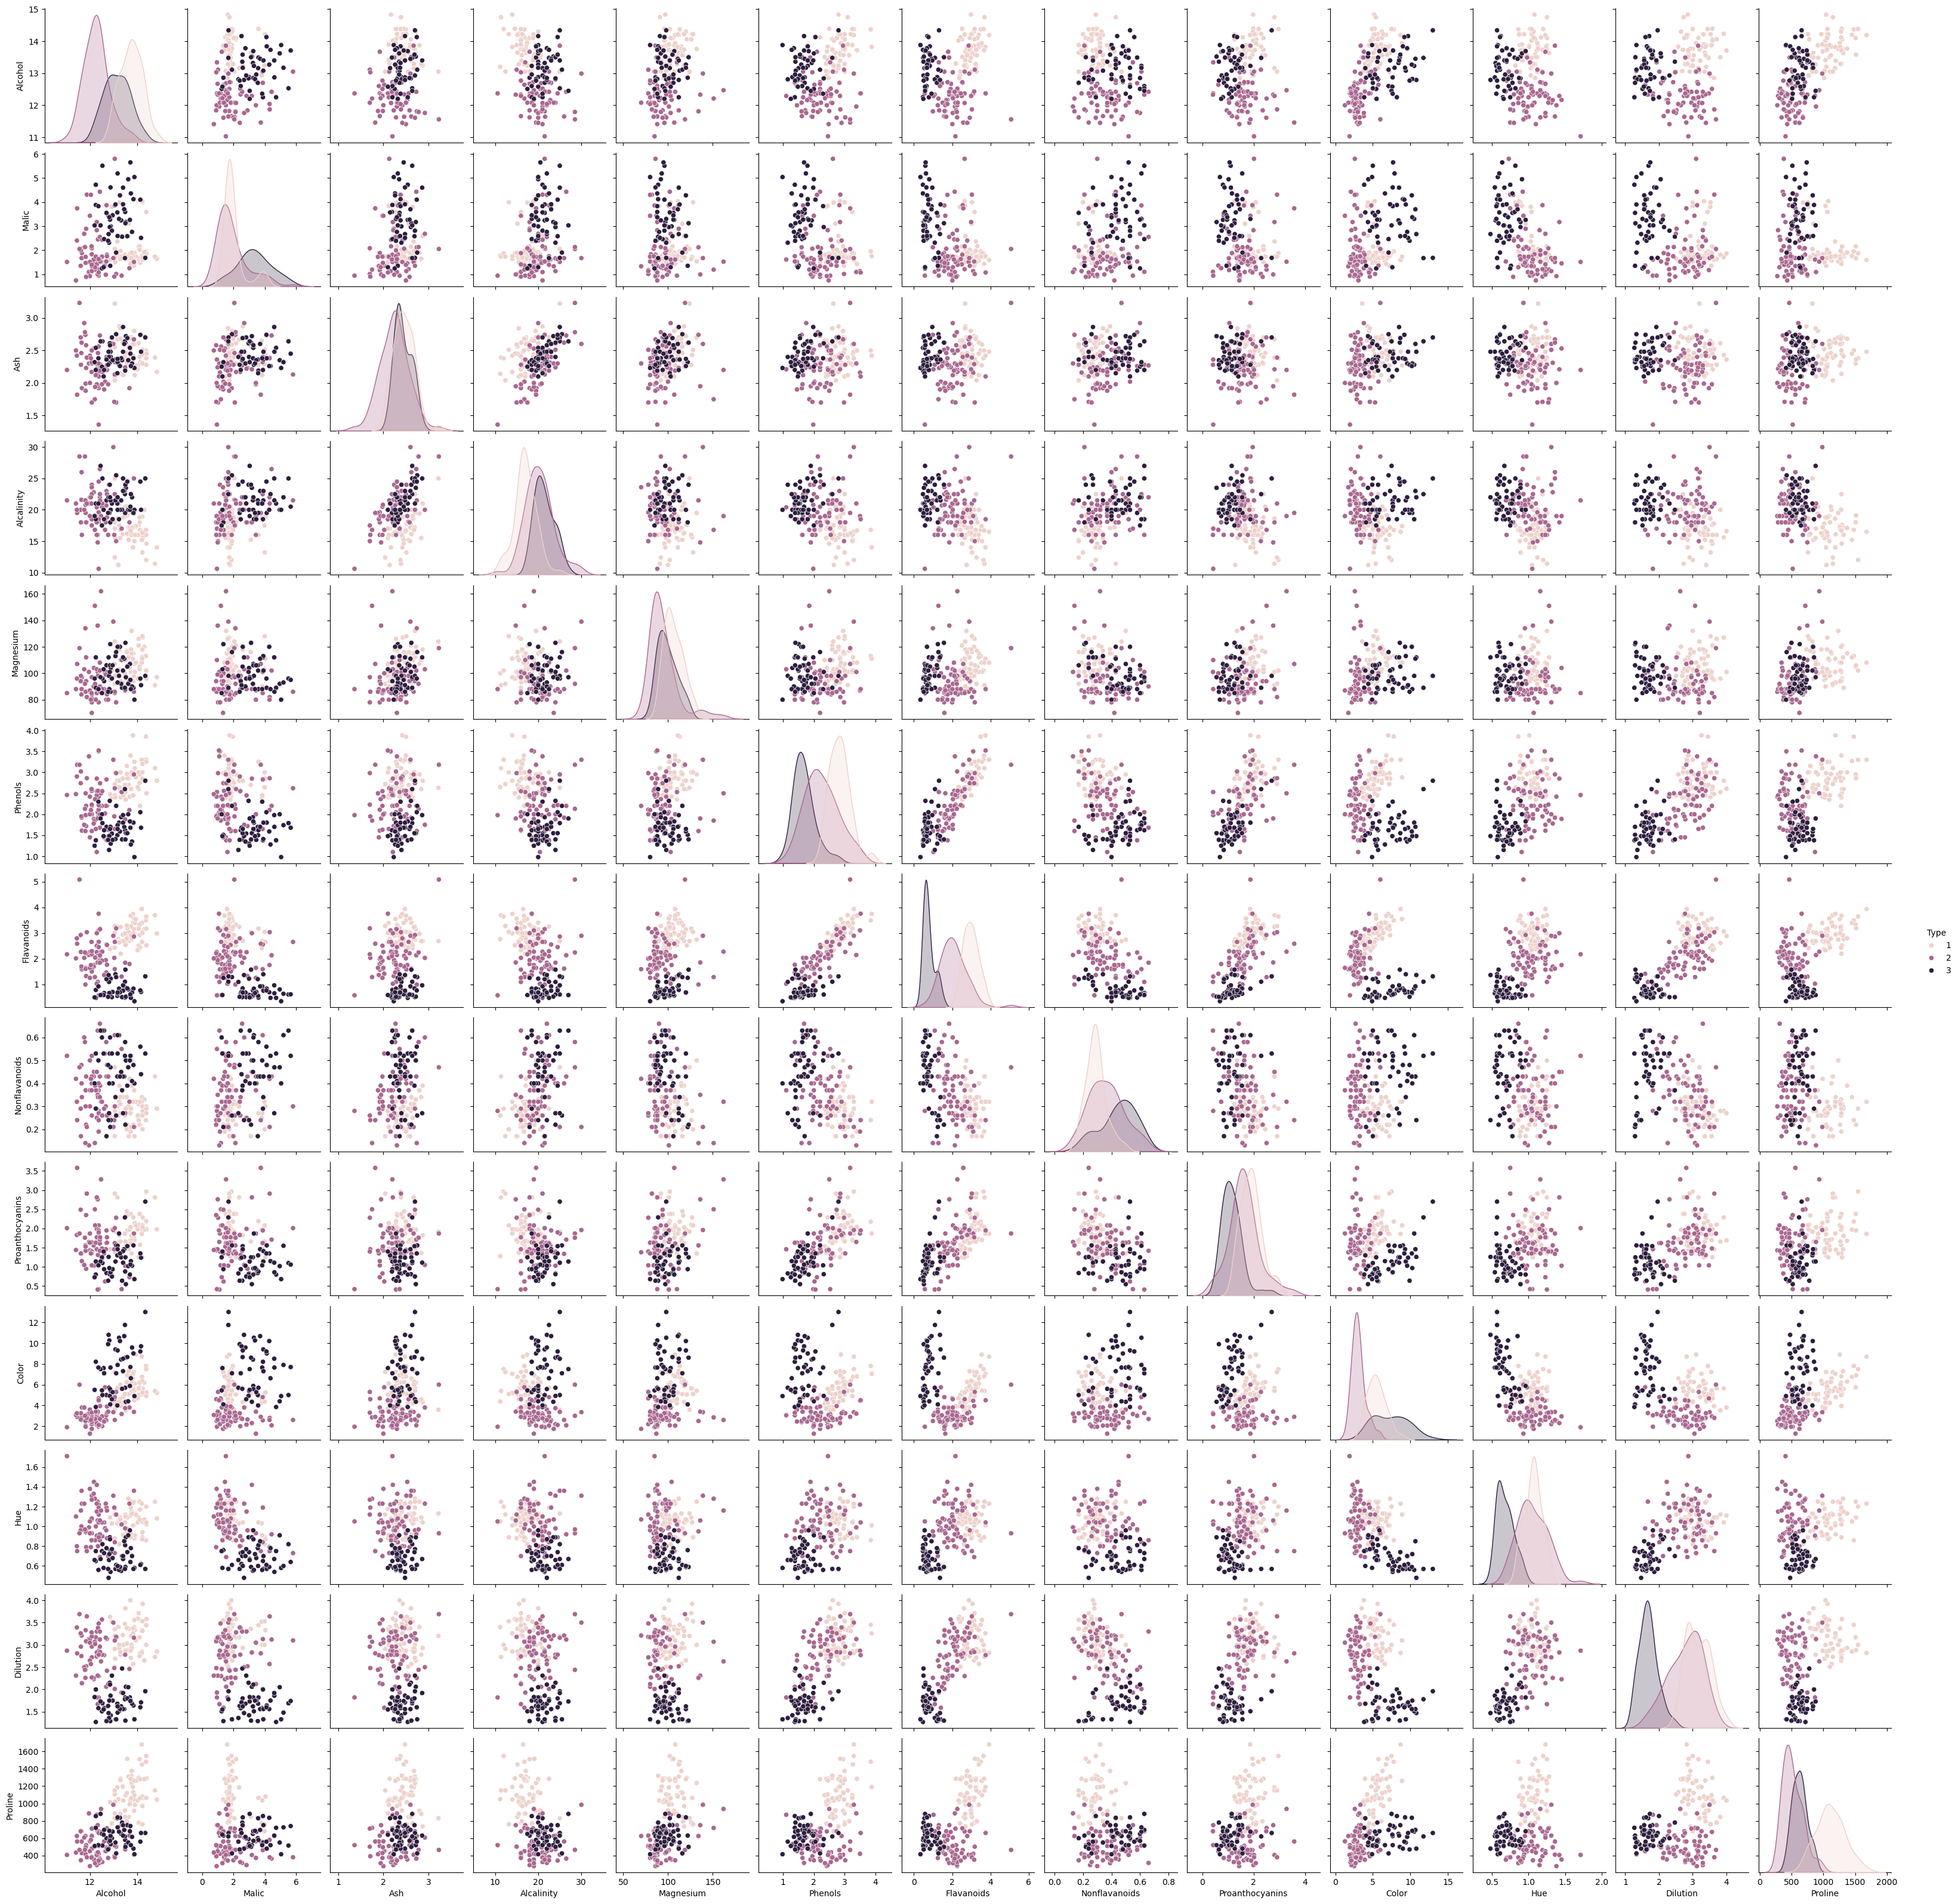

In [14]:
# pairplot
sns.pairplot(df,hue='Type')
plt.show()
#this for to see total overall relation

# Dimensionality Reduction with PCA

In [15]:
from sklearn.preprocessing import StandardScaler
X=df.drop('Type', axis=1)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)

I removed the Type column because it is the target, not a feature.
Then I scaled the data.
I did this because PCA requires all features to be on the same scale.

In [16]:
from sklearn.decomposition import PCA
# applied PCA to understand variance distribution.
pca_full = PCA()
pca_full.fit(X_scaled)

PCA()

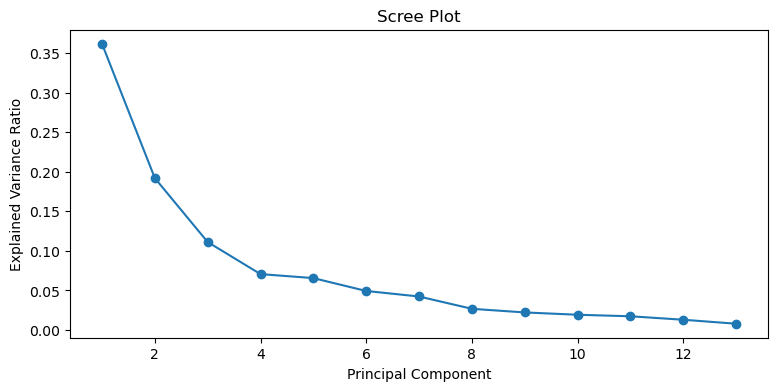

In [17]:
# scree plot
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(pca_full.explained_variance_ratio_)+1),pca_full.explained_variance_ratio_, marker='o')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.show()

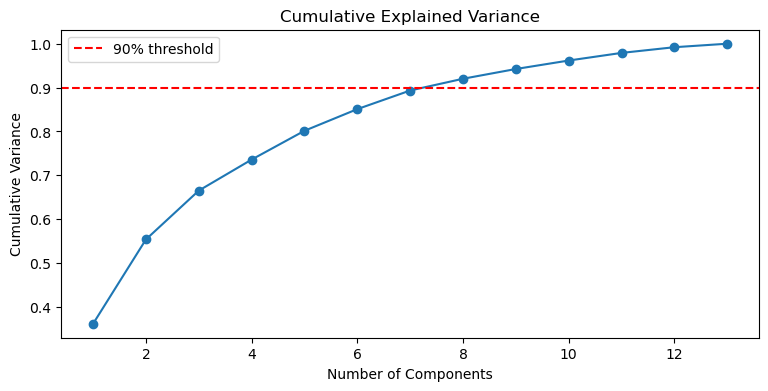

In [21]:
# cumulative explained variance to pick optimal number of components
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(9, 4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(y=0.90, color='red', linestyle='--', label='90% threshold')
plt.title('Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Variance')
plt.legend()
plt.show()

# From the scree plot and cumulative variance plot, around 2-3 components explain most of the variance. I used 2 components for easy visualization.

In [22]:
# apply PCA with 2 components
pca = PCA(n_components=2)
pca_val = pca.fit_transform(X_scaled)

In [23]:
print("Variance explained by PC1 and PC2:", pca.explained_variance_ratio_.round(4))
print("Total variance retained:", round(pca.explained_variance_ratio_.sum(), 4))

Variance explained by PC1 and PC2: [0.362  0.1921]
Total variance retained: 0.5541


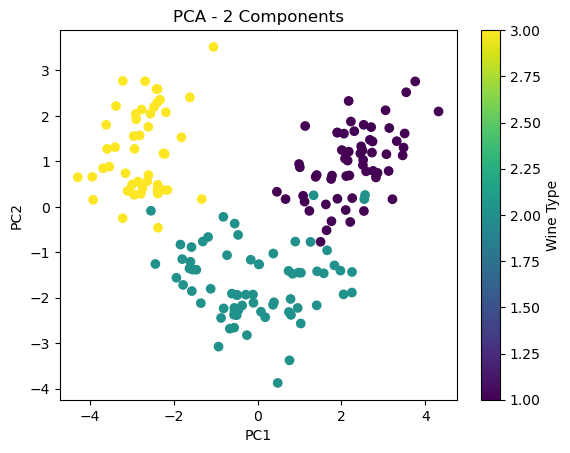

In [24]:
# scatter plot of PCA-transformed data
plt.scatter(pca_val[:, 0], pca_val[:, 1], c=df['Type'], cmap='viridis')
plt.title('PCA - 2 Components')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Wine Type')
plt.show()

# Clustering with Original Data

In [25]:
from sklearn.cluster import KMeans
# elbow method to find optimal k
inertia = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

C:\Users\shiva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shiva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shiva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\shiva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

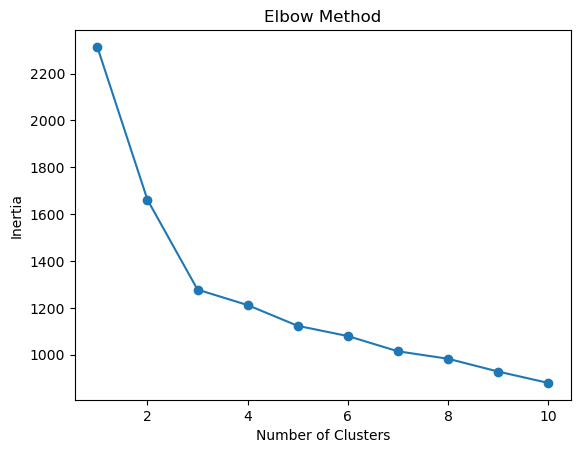

In [26]:
plt.plot(range(1, 11), inertia, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [27]:
# k=3 because elbow is at 3 and wine dataset has 3 types
kmeans = KMeans(n_clusters=3, random_state=42)
labels = kmeans.fit_predict(X_scaled)

C:\Users\shiva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


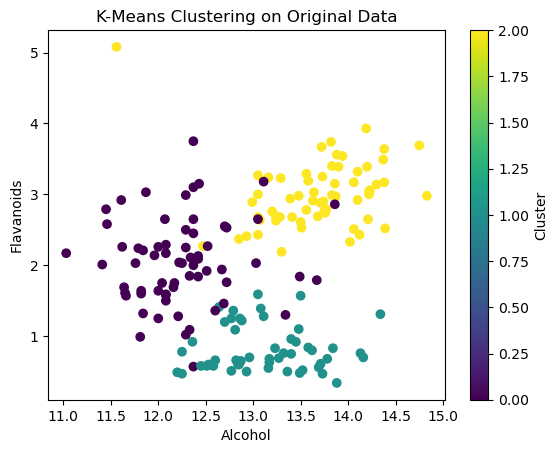

In [28]:
# visualize clustering on original data using Alcohol and Flavanoids
plt.scatter(df['Alcohol'], df['Flavanoids'], c=labels, cmap='viridis')
plt.title('K-Means Clustering on Original Data')
plt.xlabel('Alcohol')
plt.ylabel('Flavanoids')
plt.colorbar(label='Cluster')
plt.show()

In [29]:
from sklearn.metrics import silhouette_score, davies_bouldin_score
sil_orig = silhouette_score(X_scaled, labels)
db_orig  = davies_bouldin_score(X_scaled, labels)
print("Silhouette Score (original):", round(sil_orig, 4))
print("Davies-Bouldin Score (original):", round(db_orig, 4))

Silhouette Score (original): 0.2849
Davies-Bouldin Score (original): 1.3892


# Clustering with PCA Data

In [30]:
kmeans_pca = KMeans(n_clusters=3, random_state=42)
labels_pca = kmeans_pca.fit_predict(pca_val)

C:\Users\shiva\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


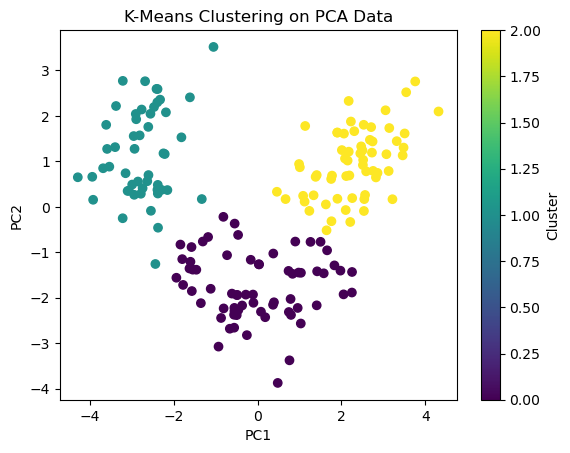

In [31]:
# visualize clustering on PCA data
plt.scatter(pca_val[:, 0], pca_val[:, 1], c=labels_pca, cmap='viridis')
plt.title('K-Means Clustering on PCA Data')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar(label='Cluster')
plt.show()

In [33]:
sil_pca = silhouette_score(pca_val, labels_pca)
db_pca  = davies_bouldin_score(pca_val, labels_pca)

In [34]:
print("Silhouette Score (PCA):", round(sil_pca, 4))
print("Davies-Bouldin Score (PCA):", round(db_pca, 4))

Silhouette Score (PCA): 0.5602
Davies-Bouldin Score (PCA): 0.5977


# Comparison and Analysis

In [35]:
comparison = pd.DataFrame({
    'Dataset'          : ['Original', 'PCA'],
    'Silhouette Score' : [round(sil_orig, 4), round(sil_pca, 4)],
    'Davies-Bouldin'   : [round(db_orig, 4),  round(db_pca, 4)]
})
comparison

,Dataset,Silhouette Score,Davies-Bouldin
0,Original,0.2849,1.3892
1,PCA,0.5602,0.5977


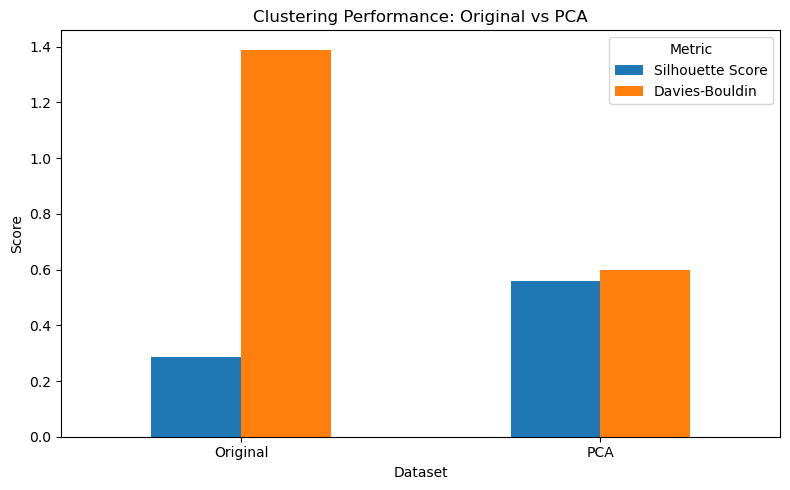

In [36]:
# bar chart comparing both
comparison.set_index('Dataset').plot(kind='bar', figsize=(8, 5))
plt.title('Clustering Performance: Original vs PCA')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

In [37]:
#Both clustering methods gave similar results. PCA-based clustering looked clearer because the data was reduced to 2 components.

In [ ]:
#Higher silhouette score and lower Davies-Bouldin score indicate better clustering. PCA showed slightly better performance.

# Conclusion:
PCA helped reduce dimensionality and made clustering easier to visualize. It works well for high-dimensional data, but some information may be lost.